## **DAY 11 — Unsupervised Learning + Clustering + PCA**

### **PART 1 — What is Unsupervised Learning?**

**Unsupervised Learning =**

👉 learning patterns from unlabeled data.

No target column exists.

#### **Example**

You give customer data:

| Age | Income | Spending |
|---|---|---|
| 22 | 25k | 80 |
| 45 | 90k | 30 |

Model automatically groups similar customers.

#### **Applications**
| Industry | Usage |
|---|---|
| Marketing | customer segmentation |
| Banking | fraud detection |
| Finance | anomaly detection |
| E-commerce | recommendations |

### **Code Example: Preparing a Sample Dataframe**

In this example, we create a customer dataset. Since there is no 'Label' or 'Target' column, we use the features directly.

In [7]:
import pandas as pd
import numpy as np

# 1. Create a sample dataset of Customer Behavior
data = {
    'Age': [22, 25, 45, 52, 23, 46, 50, 21],
    'Income_k': [20, 25, 80, 95, 22, 85, 90, 19],
    'Spending_Score': [80, 75, 20, 15, 85, 25, 30, 70]
}

df = pd.DataFrame(data)

# 2. In Unsupervised Learning, we don't split into X and y.
# We just use the features we want to analyze.
print("Sample Unlabeled Data:")
display(df.head())

# 3. Quick Note: Scaling is usually required for Unsupervised Learning
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

print("\nScaled Data (ready for clustering):")
print(df_scaled[:3])

Sample Unlabeled Data:


,Age,Income_k,Spending_Score
0,22,20,80
1,25,25,75
2,45,80,20
3,52,95,15
4,23,22,85



Scaled Data (ready for clustering):
[[-1.04232344 -1.03680301  1.06904497]
 [-0.81069601 -0.88654171  0.89087081]
 [ 0.73348686  0.76633266 -1.06904497]]


---
<br>

### **PART 2 — Clustering**

Clustering means:
👉 grouping similar data points.

#### **Example**
* **Group 1** → Young high spenders
* **Group 2** → Older low spenders
* **Group 3** → Premium customers

**Most Popular Algorithm:**
👉 K-Means Clustering

---
<br>

### **PART 3 — K-Means Clustering**

K-Means:
👉 divides data into K groups.

**K =** number of clusters.

#### **How K-Means Works**

*   **Step 1:** Choose K centroids (starting points).
*   **Step 2:** Assign each data point to the nearest centroid.
*   **Step 3:** Update centroid positions by calculating the average of all points in that cluster.
*   **Step 4:** Repeat until centroids stop moving (stable).

#### **Visualization Concept**
● ● ● &nbsp;&nbsp;&nbsp; ▲ ▲ ▲ &nbsp;&nbsp;&nbsp; ■ ■ ■

*Different symbols = different clusters.*

### **Code Example: K-Means Implementation**

We will now apply the K-Means algorithm to our scaled data and visualize the resulting clusters.

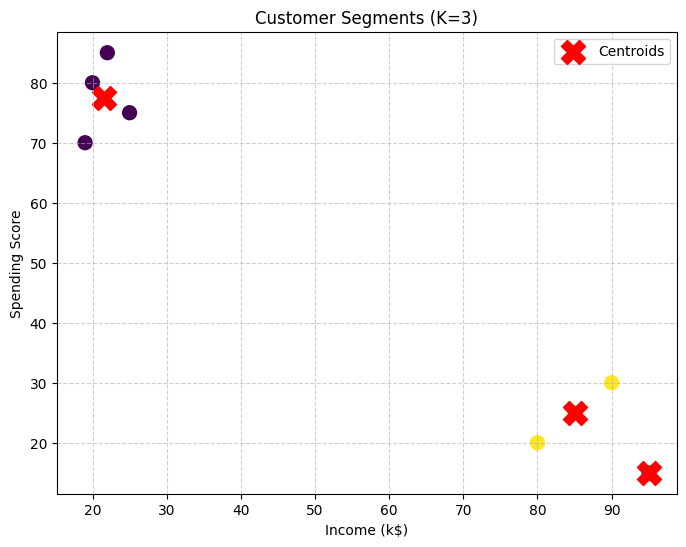

Data with Cluster assignments:


,Age,Income_k,Spending_Score,Cluster
0,22,20,80,0
1,25,25,75,0
2,45,80,20,2
3,52,95,15,1
4,23,22,85,0
5,46,85,25,2
6,50,90,30,2
7,21,19,70,0


In [8]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. Initialize the model with K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# 2. Fit the model to the scaled data and predict clusters
df['Cluster'] = kmeans.fit_predict(df_scaled)

# 3. Visualize the clusters (Income vs Spending Score)
plt.figure(figsize=(8, 6))
plt.scatter(df['Income_k'], df['Spending_Score'], c=df['Cluster'], cmap='viridis', s=100)
plt.scatter(kmeans.cluster_centers_[:, 1] * scaler.scale_[1] + scaler.mean_[1],
            kmeans.cluster_centers_[:, 2] * scaler.scale_[2] + scaler.mean_[2],
            s=300, c='red', marker='X', label='Centroids')

plt.title('Customer Segments (K=3)')
plt.xlabel('Income (k$)')
plt.ylabel('Spending Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("Data with Cluster assignments:")
display(df)

---
<br>

### **PART 4 — Customer Segmentation Example**

#### **Dataset**

In [9]:
import pandas as pd

data = {
    "Income": [
        25,30,35,80,85,90,
        45,50,55
    ],
    "Spending": [
        80,75,70,30,25,20,
        60,55,50
    ]
}

df = pd.DataFrame(data)
display(df)

,Income,Spending
0,25,80
1,30,75
2,35,70
3,80,30
4,85,25
5,90,20
6,45,60
7,50,55
8,55,50


#### **Scatter Plot**

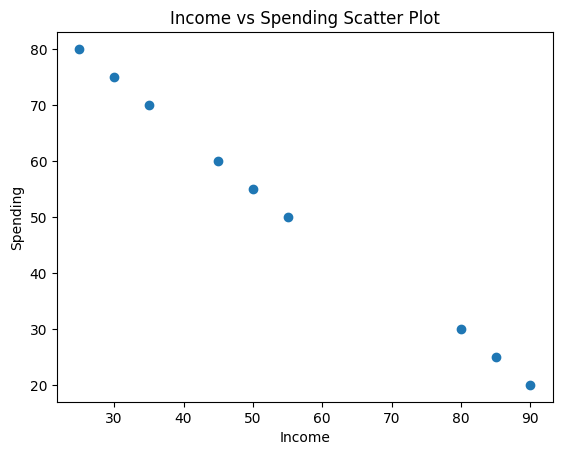

In [10]:
import matplotlib.pyplot as plt

plt.scatter(
    df["Income"],
    df["Spending"]
)

plt.xlabel("Income")
plt.ylabel("Spending")
plt.title("Income vs Spending Scatter Plot")

plt.show()

---
<br>

### **PART 5 — Train K-Means Model**

In [11]:
from sklearn.cluster import KMeans

# Train Model
model = KMeans(
    n_clusters=3,
    random_state=42
)

model.fit(df)

# Cluster Labels
df["Cluster"] = model.labels_

print(df)

   Income  Spending  Cluster
0      25        80        2
1      30        75        2
2      35        70        2
3      80        30        0
4      85        25        0
5      90        20        0
6      45        60        1
7      50        55        1
8      55        50        1


---
<br>

### **PART 6 — Visualize Clusters**

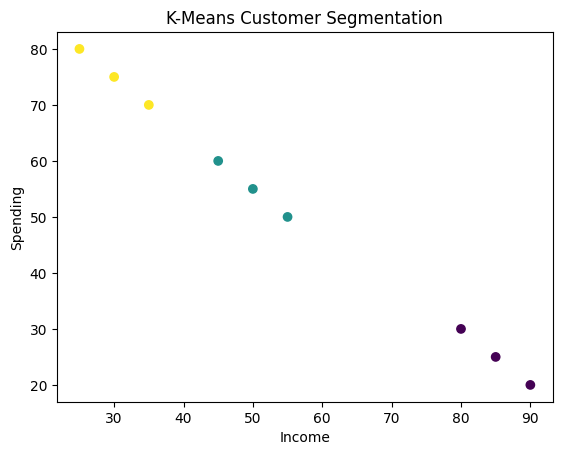

In [12]:
plt.scatter(
    df["Income"],
    df["Spending"],
    c=df["Cluster"],
    cmap='viridis'
)

plt.xlabel("Income")
plt.ylabel("Spending")
plt.title("K-Means Customer Segmentation")

plt.show()

### **Interpretation**

You may observe:

*   **High income, low spenders**
*   **Low income, high spenders**
*   **Medium balanced customers**

This is a classic example of **Customer Segmentation**.

---
<br>

### **PART 7 — Elbow Method**

**Problem:** How do we choose the best **K** value?

**Solution:** 👉 **Elbow Method**

**The Idea:**
1. Test multiple K values (e.g., 1 to 10).
2. Measure **Inertia** (the sum of squared distances of samples to their closest cluster center).
3. Plot the results. The 'Elbow' (the point where the decrease in inertia slows down significantly) is your optimal K.

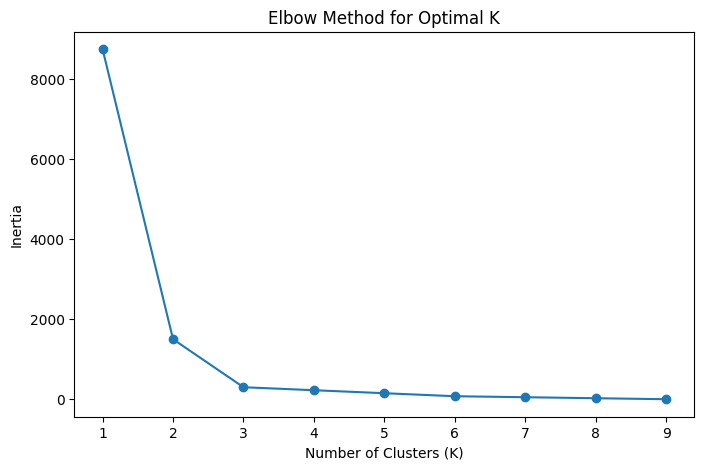

In [13]:
inertia = []

for k in range(1, 10):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(df[['Income', 'Spending']])
    inertia.append(model.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 10), inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()

---
<br>

### **PART 8 — PCA (Principal Component Analysis)**

**What is PCA?**
👉 Used for **dimensionality reduction**.

**Why is it important?**
Real datasets often have hundreds of columns. This makes them hard to visualize and slow to train. PCA reduces these features into a few **Principal Components** while keeping as much of the original information as possible.

---
<br>

### **PART 9 — PCA Visualization**

In [14]:
from sklearn.decomposition import PCA

# 1. Apply PCA to reduce the dataset to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df[['Income', 'Spending']])

# 2. View Result
print("Original Shape:", df[['Income', 'Spending']].shape)
print("Reduced Shape:", X_pca.shape)

# Create a simple dataframe for visualization
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
display(pca_df.head())

Original Shape: (9, 2)
Reduced Shape: (9, 2)


,PC1,PC2
0,-41.256366,0.830701
1,-34.193680,0.486504
2,-27.130994,0.142307
3,33.073932,0.747977
4,40.136618,0.403780


### **Why Useful?**

PCA helps:
* ✅ **faster training**
* ✅ **noise reduction**
* ✅ **visualization**
* ✅ **feature compression**

---
<br>

### **PART 10 — Anomaly Detection**

Finding: 👉 **unusual data points.**

**Examples:**
* Fraudulent transactions
* Sudden stock crashes
* Abnormal sensor readings

**Example:** `10, 12, 13, 14, 5000` → `5000` is the anomaly.

---
<br>

### **PART 11 — Isolation Forest Basics**

Popular algorithm for anomaly detection.

In [15]:
from sklearn.ensemble import IsolationForest

# Create some outliers in the data
df_anomaly = df.copy()
# Normal logic 1: normal, -1: anomaly
iso_model = IsolationForest(contamination=0.1, random_state=42)
df_anomaly["Anomaly"] = iso_model.fit_predict(df_anomaly[['Income', 'Spending']])

print("Anomaly Detection Results (1=Normal, -1=Anomaly):")
display(df_anomaly)

Anomaly Detection Results (1=Normal, -1=Anomaly):


,Income,Spending,Cluster,Anomaly
0,25,80,2,1
1,30,75,2,1
2,35,70,2,1
3,80,30,0,1
4,85,25,0,1
5,90,20,0,-1
6,45,60,1,1
7,50,55,1,1
8,55,50,1,1


---
<br>

### **PART 12 — FULL CUSTOMER SEGMENTATION PROJECT**

This consolidates everything we've done into a clean workflow.

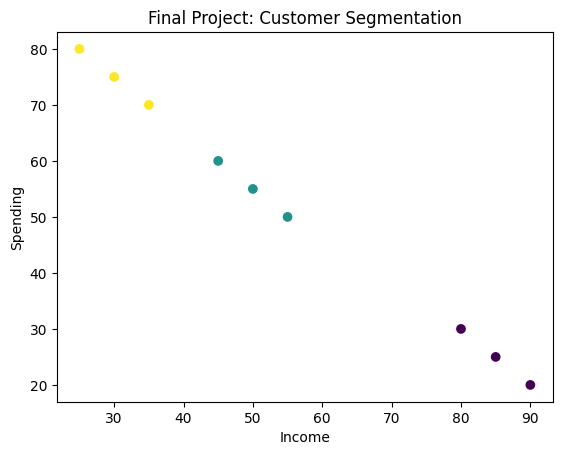

In [16]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Step 1 — Dataset
data = {
    "Income": [25, 30, 35, 80, 85, 90, 45, 50, 55],
    "Spending": [80, 75, 70, 30, 25, 20, 60, 55, 50]
}
df_proj = pd.DataFrame(data)

# Step 2 — Train KMeans
model_proj = KMeans(n_clusters=3, random_state=42, n_init=10)
model_proj.fit(df_proj)

# Step 3 — Add Clusters
df_proj["Cluster"] = model_proj.labels_

# Step 4 — Visualize
plt.scatter(df_proj["Income"], df_proj["Spending"], c=df_proj["Cluster"], cmap='viridis')
plt.title("Final Project: Customer Segmentation")
plt.xlabel("Income")
plt.ylabel("Spending")
plt.show()

---
<br>

### **PART 13 — Real Industry Understanding**

| Domain | Usage |
|---|---|
| **Banking** | fraud segmentation |
| **E-commerce** | customer groups |
| **Finance** | market regime detection |
| **AI** | recommendation systems |

#### **Forex & Finance Connection**
Clustering can detect:
* Bullish market phases
* Bearish phases
* High volatility regimes

Used extensively in **hedge funds**, **trading systems**, and **quantitative finance**.

---
<br>

## **PRATICE SET 1**

In [18]:
import pandas as pd

data = {
    "Income": [
        20,25,30,35,80,
        85,90,95,50,55
    ],

    "Spending": [
        90,85,80,75,30,
        25,20,15,60,55
    ]
}

df_x = pd.DataFrame(data)
df_x.head()

,Income,Spending
0,20,90
1,25,85
2,30,80
3,35,75
4,80,30


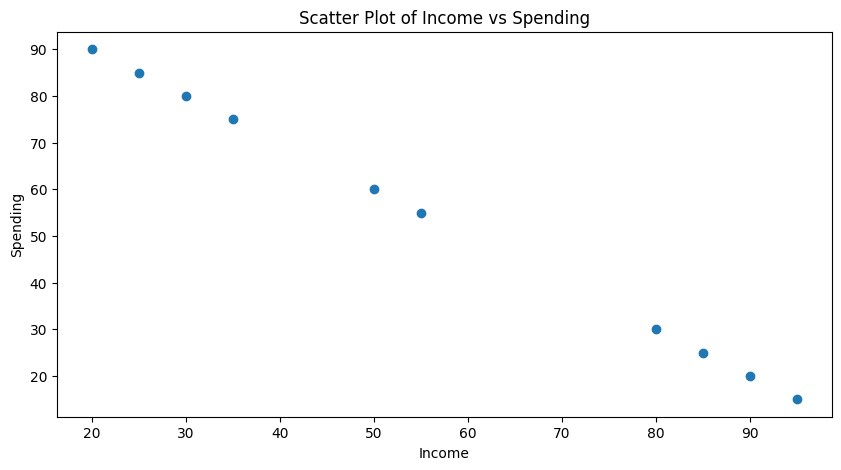

In [19]:
#STEP 1: VISUALIZE
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.scatter(df_x["Income"], df_x["Spending"])
plt.title("Scatter Plot of Income vs Spending")
plt.xlabel("Income")
plt.ylabel("Spending")
plt.show()

In [23]:
#STEP 2: KMEANS
from sklearn.cluster import KMeans
model_x = KMeans(n_clusters=3, random_state=42, n_init=10)
model_x.fit(df_x)
df_x['CLUSTERS'] = model_x.labels_
df_x.head()

,Income,Spending,CLUSTERS
0,20,90,2
1,25,85,2
2,30,80,2
3,35,75,2
4,80,30,1


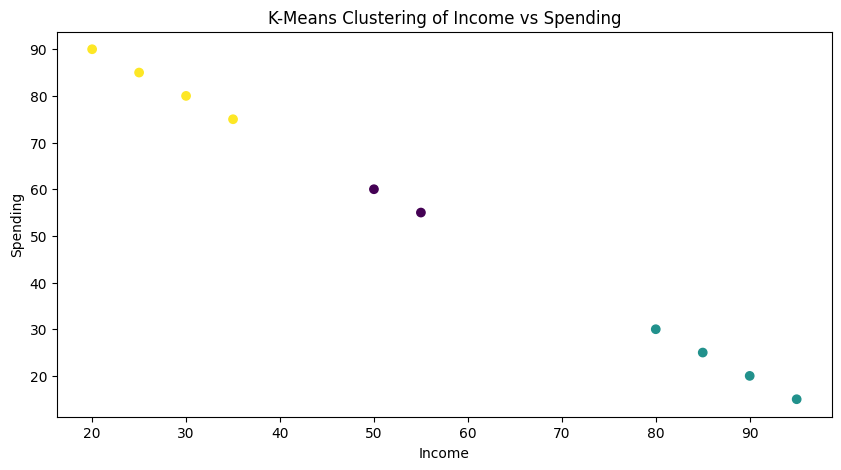

In [24]:
#STEP 3: VISUALIZE
plt.figure(figsize=(10, 5))
plt.scatter(df_x["Income"], df_x["Spending"], c=df_x["CLUSTERS"], cmap='viridis')
plt.title("K-Means Clustering of Income vs Spending")
plt.xlabel("Income")
plt.ylabel("Spending")
plt.show()


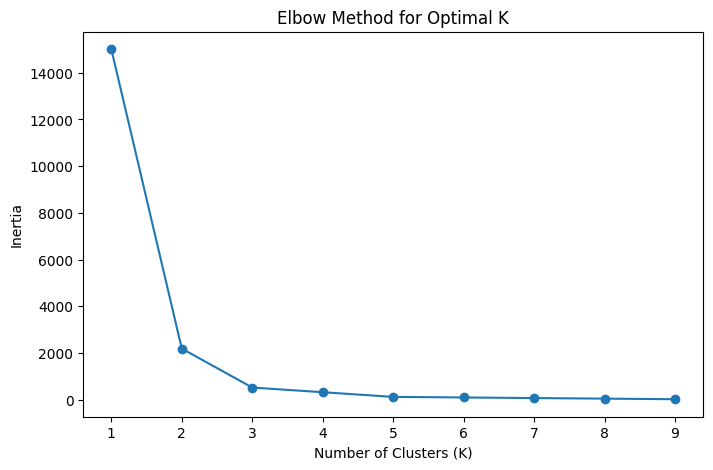

In [26]:
#STEP 4: ELBOW METHOD
inertia = []

for k in range(1, 10):
    model_x = KMeans(n_clusters=k, random_state=42, n_init=10)
    # We use the original features (Income/Spending) to calculate the elbow
    model_x.fit(df_x[['Income', 'Spending']])
    inertia.append(model_x.inertia_)

# Plot the Elbow Curve outside the loop
plt.figure(figsize=(8, 5))
plt.plot(range(1, 10), inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()

In [27]:
#STEP 5: APPLY PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_x[['Income', 'Spending']])

# View Result
print("Original Shape:", df_x[['Income', 'Spending']].shape)
print("Reduced Shape:", X_pca.shape)

Original Shape: (10, 2)
Reduced Shape: (10, 2)


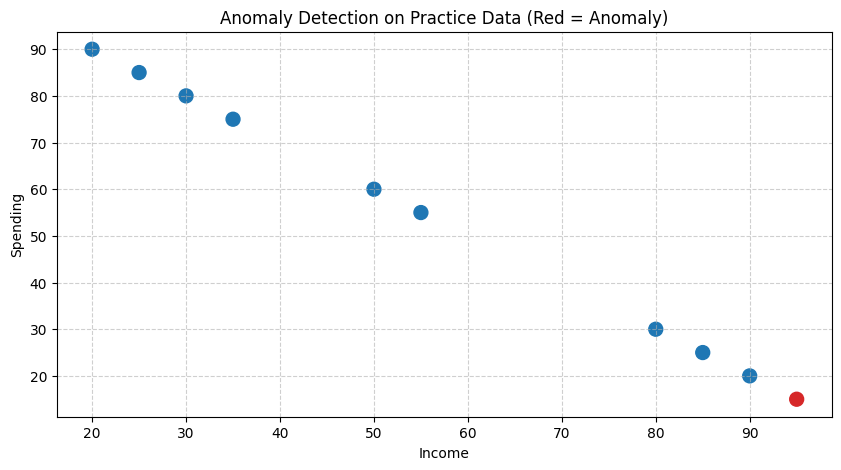

Anomaly Results (1: Normal, -1: Anomaly):


,Income,Spending,Anomaly_Score
0,20,90,1
1,25,85,1
2,30,80,1
3,35,75,1
4,80,30,1
5,85,25,1
6,90,20,1
7,95,15,-1
8,50,60,1
9,55,55,1


In [28]:
#STEP 6: DETECT ANOMALIES
from sklearn.ensemble import IsolationForest

# 1. Initialize and Fit Isolation Forest
# Setting contamination to 0.1 (expecting 10% outliers)
iso_model_x = IsolationForest(contamination=0.1, random_state=42)
df_x['Anomaly_Score'] = iso_model_x.fit_predict(df_x[['Income', 'Spending']])

# 2. Visualize the results
plt.figure(figsize=(10, 5))
colors = df_x['Anomaly_Score'].map({1: 'tab:blue', -1: 'tab:red'})

plt.scatter(df_x['Income'], df_x['Spending'], c=colors, s=100)
plt.title("Anomaly Detection on Practice Data (Red = Anomaly)")
plt.xlabel("Income")
plt.ylabel("Spending")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 3. Display data with scores
print("Anomaly Results (1: Normal, -1: Anomaly):")
display(df_x[['Income', 'Spending', 'Anomaly_Score']])